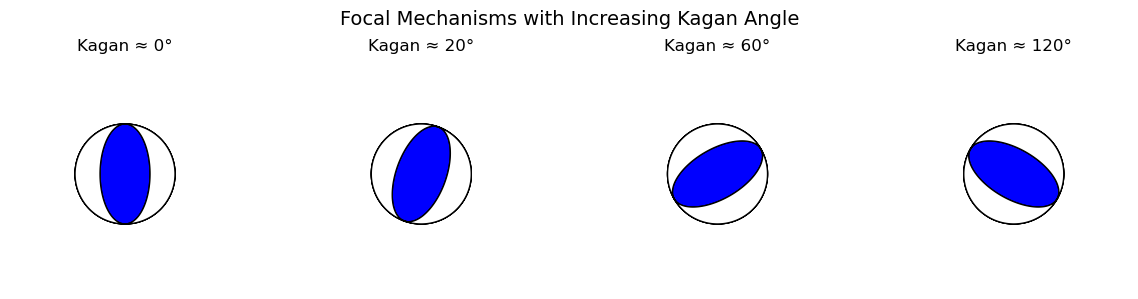

In [1]:
import matplotlib.pyplot as plt
from obspy.imaging.beachball import beach
import numpy as np

# Define reference focal mechanism (strike, dip, rake)
ref = [0, 45, 90]

# Define other mechanisms with estimated Kagan angle differences
fms = [
    [0, 45, 90],    # 0°
    [20, 45, 90],   # ~20°
    [60, 45, 90],   # ~60°
    [120, 45, 90],  # ~120°
]

# Plot
fig, axs = plt.subplots(1, 4, figsize=(12, 3))
angles = [0, 20, 60, 120]  # Approximate labels

for i, (fm, ax) in enumerate(zip(fms, axs)):
    # Convert to moment tensor-like input
    b = beach(fm, xy=(0, 0), width=100, linewidth=1, facecolor='b', nofill=False, zorder=10, axes=ax)
    ax.add_collection(b)
    ax.set_xlim(-100, 100)
    ax.set_ylim(-100, 100)
    ax.set_aspect('equal')
    ax.set_title(f"Kagan ≈ {angles[i]}°", fontsize=12)
    ax.axis('off')

plt.suptitle("Focal Mechanisms with Increasing Kagan Angle", fontsize=14)
plt.tight_layout()
plt.show()



In [3]:
import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# Quaternion helpers (faithful to Kagan, 1991)
# ------------------------------------------------------------------
def quat_fps(strk, dip, rake):
    """Strike–dip–rake (deg) ➜ quaternion (x,y,z,w)."""
    DD, DA, SA = map(np.deg2rad, (strk, dip, rake))
    CDD, SDD, CDA, SDA = np.cos(DD), np.sin(DD), np.cos(DA), np.sin(DA)
    CSA, SSA = np.cos(SA), np.sin(SA)
    S1 = CSA*SDD - SSA*CDA*CDD
    S2 = -CSA*CDD - SSA*CDA*SDD
    S3 = -SSA*SDA
    V1, V2, V3 = SDA*CDD, SDA*SDD, -CDA
    AN1, AN2, AN3 = S2*V3 - V2*S3, V1*S3 - S1*V3, S1*V2 - V1*S2
    D2 = 1/np.sqrt(2)
    T1, T2, T3 = (V1+S1)*D2, (V2+S2)*D2, (V3+S3)*D2
    P1, P2, P3 = (V1-S1)*D2, (V2-S2)*D2, (V3-S3)*D2
    U0 = (T1+P2+AN3+1)/4;  U1 = (T1-P2-AN3+1)/4
    U2 = (-T1+P2-AN3+1)/4; U3 = (-T1-P2+AN3+1)/4
    UM = max(U0, U1, U2, U3)
    if np.isclose(UM, U0):
        U0 = np.sqrt(U0); U3 = (T2-P1)/(4*U0); U2 = (AN1-T3)/(4*U0); U1 = (P3-AN2)/(4*U0)
    elif np.isclose(UM, U1):
        U1 = np.sqrt(U1); U2 = (T2+P1)/(4*U1); U3 = (AN1+T3)/(4*U1); U0 = (P3-AN2)/(4*U1)
    elif np.isclose(UM, U2):
        U2 = np.sqrt(U2); U1 = (T2+P1)/(4*U2); U0 = (AN1-T3)/(4*U2); U3 = (P3+AN2)/(4*U2)
    else:  # UM == U3
        U3 = np.sqrt(U3); U0 = (T2-P1)/(4*U3); U1 = (AN1+T3)/(4*U3); U2 = (P3+AN2)/(4*U3)
    q = np.array([U1, U2, U3, U0])
    return q / np.linalg.norm(q)

def qmul(q1, q2):
    """Quaternion product Q3 = Q2 * Q1 (order matches Kagan’s script)."""
    x1,y1,z1,w1 = q1; x2,y2,z2,w2 = q2
    return np.array([
        w1*x2 + z1*y2 - y1*z2 + x1*w2,
       -z1*x2 + w1*y2 + x1*z2 + y1*w2,
        y1*x2 - x1*y2 + w1*z2 + z1*w2,
       -x1*x2 - y1*y2 - z1*z2 + w1*w2])

def qdiv(q1, q2):             # Q3 = Q2 * q1⁻¹
    qc1 = np.array([-q1[0], -q1[1], -q1[2],  q1[3]])
    return qmul(qc1, q2)

def box_test(q, code):
    """Return equivalent quaternion for DC symmetry branch `code` (1–4)."""
    SYM = np.array([[1,0,0],[0,1,0],[0,0,1],[0,0,0]], float)
    if code == 0: code = np.argmax(np.abs(q[:3])) + 1
    q2 = q.copy() if code == 4 else qmul(SYM[:, code-1], q)
    return (-q2 if q2[3] < 0 else q2)

def sph(q):
    """Quaternion ➜ (rotation°, theta°, phi°)."""
    if q[3] < 0: q = -q
    rot = 2*np.degrees(np.arccos(np.clip(q[3], -1, 1)))
    q4n = np.sqrt(max(0, 1-q[3]**2))
    costh = q[2]/q4n if q4n > 1e-10 else 1
    theta = np.degrees(np.arccos(np.clip(costh, -1, 1)))
    phi = np.degrees(np.arctan2(q[1], q[0])) % 360
    return rot, theta, phi

def kagan(m1, m2):
    q1, q2 = map(lambda m: quat_fps(*m), (m1, m2))
    best = min((sph(qdiv(box_test(q1,i), q2))[0] for i in range(1,5)))
    return best
# ------------------------------------------------------------------

# ―― Define idealised mechanisms ――
MECH = {
    "Normal"     : [0, 60, -90],   # extensional
    "Reverse"    : [0, 60,  90],   # compressional
    "Strike-Slip": [0, 90,   0],   # right-lateral, vertical plane
}

names = list(MECH)
K = np.zeros((3,3))
for i, ni in enumerate(names):
    for j, nj in enumerate(names):
        K[i,j] = kagan(MECH[ni], MECH[nj])

print(pd.DataFrame(K, index=names, columns=names).round(2))


             Normal  Reverse  Strike-Slip
Normal         0.00    90.00        93.84
Reverse       90.00     0.00        93.84
Strike-Slip   93.84    93.84         0.00
